# GDN-2 (Gated DeltaNet-2) — training a ~70M‑parameter model on enwik8

This notebook is a self-contained guide: it installs the published package
[`atomic-ops`](https://pypi.org/project/atomic-ops/) (`pip install atomic-ops`,
source: [`atomic_ops` on GitHub](https://github.com/Akseleu-J/atomic_ops))
and uses it to train a byte‑level language model (~70M parameters) on
**enwik8**, tracking **bits‑per‑byte (bpb)** on a held‑out validation split.

It targets **Kaggle TPU v5e-8**, but thanks to the package's auto‑fallback
(`gdn2_forward_trainable`) the same code also runs (more slowly) on CPU/GPU —
handy for local debugging with a small `seq_len`/`batch_size`.

**Contents:**
1. Install dependencies.
2. Configuration, **including the data‑parallel mesh switch** (see note below).
3. Download/prepare enwik8.
4. A simple but real architecture: a stack of
   `RMSNorm → GDN‑2 mixer → residual`, `RMSNorm → gated MLP → residual`
   blocks, byte embedding, tied lm‑head.
5. A plateau‑adaptive LR schedule (warmup → peak → ReduceLROnPlateau).
6. A full training loop with gradient clipping, a non‑finite guard (skip
   the step on NaN/Inf instead of crashing the run) and checkpoints.
7. Train/val bpb plots.
8. **Results** — actual numbers from a training run on Kaggle TPU v5e-8.

> Note on model size: the config below is tuned to land at **≈70M parameters**,
> but you can adjust `num_layers` / `mlp_mult` in `MODEL_CONFIG` to reach
> a different size (e.g., the cell prints a hint to hit **~75M** more precisely).
> The hard requirement for the Pallas kernel is `d_head=128` (so `d_model`
> must be a multiple of 128).

> **Note on the data‑parallel mesh (`USE_MESH`):** on a multi‑chip TPU
> slice (e.g. Kaggle's TPU v5e‑8, 8 chips), running everything through a
> single `jax.jit` with no explicit sharding places all compute on a
> single chip — the other 7 sit idle. This notebook auto‑detects the
> number of visible devices (`USE_MESH = "auto"`) and, when more than one
> device is available, builds a `Mesh` and runs the GDN‑2 mixer through
> `jax.shard_map` (data‑parallel across the batch axis), the same pattern
> used in the project's own `train_gdn2_100m.py` script. On
> CPU/GPU/a single TPU chip it transparently falls back to plain
> `jax.jit` with no sharding (`USE_MESH=False`‑equivalent) — nothing else
> in the notebook needs to change. You can also force it manually
> (`USE_MESH = True` / `USE_MESH = False`), the same way `interpret=True`
> lets you force CPU execution of the Pallas kernels in the package's own
> test suite.

## 1. Install dependencies

In [1]:
# atomic-ops: fused GDN-2 kernels (TPU) + pure-JAX fallback (CPU/GPU).
# flax/optax: model and optimizer. No `requests` needed - we use urllib.
!pip install -q -U atomic-ops "flax>=0.8.0" "optax>=0.2.0" "libtpu>=0.0.46"


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, sys, time, math, json, pickle, zipfile, urllib.request
from functools import partial
from collections import deque

import numpy as np
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax

from jax.experimental import mesh_utils
from jax.sharding import Mesh, NamedSharding
from jax.sharding import PartitionSpec as P

import atomic_ops
from atomic_ops import gdn2_forward_trainable, get_recommended_config, is_tpu_available

print("JAX version:", jax.__version__)
print("atomic_ops (atomic-ops) version:", atomic_ops.__version__)
print("Devices:", jax.devices())
print("TPU available (Pallas fast path):", is_tpu_available())


/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:90: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


JAX version: 0.11.1
atomic_ops (atomic-ops) version: 0.1.0


E0000 00:00:1788749919.367401      73 common_lib.cc:957] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:239


Devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0), TpuDevice(id=1, process_index=0, coords=(1,0,0), core_on_chip=0), TpuDevice(id=2, process_index=0, coords=(0,1,0), core_on_chip=0), TpuDevice(id=3, process_index=0, coords=(1,1,0), core_on_chip=0), TpuDevice(id=4, process_index=0, coords=(0,2,0), core_on_chip=0), TpuDevice(id=5, process_index=0, coords=(1,2,0), core_on_chip=0), TpuDevice(id=6, process_index=0, coords=(0,3,0), core_on_chip=0), TpuDevice(id=7, process_index=0, coords=(1,3,0), core_on_chip=0)]
TPU available (Pallas fast path): True


## 2. Configuration

`d_model = n_heads * 128` is mandatory (the GDN-2 Pallas kernel requires
`d_head=128`). `seq_len` must be divisible by the kernel's chunk size
(`atomic_ops.configs.DEFAULT_CONFIG.bt`, 256 by default).

### Data-parallel mesh switch

`USE_MESH`:
- `"auto"` (default) — use a data-parallel mesh across **all visible
  devices** if `is_tpu_available()` and more than one device is visible
  (e.g. Kaggle TPU v5e-8 -> 8 chips). Otherwise (CPU, GPU, single TPU
  chip) runs with no mesh at all, exactly like before.
- `True` — force the mesh path even if only one device is visible (mostly
  useful for debugging the sharding code itself; with 1 device it's a
  no-op mesh).
- `False` — force plain (unsharded) execution even on an 8-chip TPU, so
  you can measure the single-chip baseline the mesh is meant to beat.


In [3]:
from atomic_ops.configs import DEFAULT_CONFIG as _GDN2_CFG
GDN2_CHUNK = _GDN2_CFG.bt  # 256 by default (KAGGLE_MEDIUM)

MODEL_CONFIG = dict(
    vocab_size=256,      # byte-level
    d_model=768,
    n_heads=6,           # d_head = d_model / n_heads = 128 (required by the Pallas kernel)
    num_layers=7,        # see the param-count check below; tune to your budget
    mlp_mult=3,          # MLP hidden size = mlp_mult * d_model
    dropout_rate=0.0,
)
assert MODEL_CONFIG["d_model"] % MODEL_CONFIG["n_heads"] == 0
assert MODEL_CONFIG["d_model"] // MODEL_CONFIG["n_heads"] == 128, \
    "d_head must be 128 -- a hard requirement of the atomic_ops Pallas kernel"

RUN_CONFIG = dict(
    run_name=f"gdn2_75m_enwik8_{time.strftime('%Y%m%d_%H%M%S')}",
    seq_len=2048,                 # must be divisible by GDN2_CHUNK
    micro_batch_size=8,           # lower this if you hit OOM; must divide evenly across devices when mesh is on
    accum_steps=4,                # effective batch = micro_batch_size * accum_steps
    total_train_steps=3000,
    warmup_steps=300,
    peak_lr=3e-4,
    min_lr=1e-6,
    lr_reduce_factor=0.5,
    patience=3,                   # evals without improvement before an LR reduction
    lr_cooldown_steps=400,
    weight_decay=0.01,
    grad_clip_norm=1.0,
    eval_every_steps=200,
    eval_batches=20,
    eval_seed=999,
    ckpt_every_seconds=900,
    nonfinite_consecutive_limit=6,
    nonfinite_window_size=20,
    nonfinite_window_ratio=0.3,
    val_split=0.02,
    seed=42,
    data_dir="/kaggle/working/enwik8_data",
    ckpt_dir="/kaggle/working/gdn2_75m_ckpt",
)
assert RUN_CONFIG["seq_len"] % GDN2_CHUNK == 0, \
    f"seq_len={RUN_CONFIG['seq_len']} must be divisible by GDN2_CHUNK={GDN2_CHUNK}"

os.makedirs(RUN_CONFIG["data_dir"], exist_ok=True)
os.makedirs(RUN_CONFIG["ckpt_dir"], exist_ok=True)
print(json.dumps(RUN_CONFIG, indent=2))


{
  "run_name": "gdn2_75m_enwik8_20260907_025848",
  "seq_len": 2048,
  "micro_batch_size": 8,
  "accum_steps": 4,
  "total_train_steps": 3000,
  "warmup_steps": 300,
  "peak_lr": 0.0003,
  "min_lr": 1e-06,
  "lr_reduce_factor": 0.5,
  "patience": 3,
  "lr_cooldown_steps": 400,
  "weight_decay": 0.01,
  "grad_clip_norm": 1.0,
  "eval_every_steps": 200,
  "eval_batches": 20,
  "eval_seed": 999,
  "ckpt_every_seconds": 900,
  "nonfinite_consecutive_limit": 6,
  "nonfinite_window_size": 20,
  "nonfinite_window_ratio": 0.3,
  "val_split": 0.02,
  "seed": 42,
  "data_dir": "/kaggle/working/enwik8_data",
  "ckpt_dir": "/kaggle/working/gdn2_75m_ckpt"
}


In [4]:
# ==========================================================================
# Data-parallel mesh setup.
#
# "auto" -> mesh across ALL visible devices if is_tpu_available() and more
#           than one device is visible (e.g. Kaggle TPU v5e-8 -> 8 chips).
# True   -> force mesh path (useful for debugging the sharding code with
#           a single device -- becomes a trivial 1-device mesh).
# False  -> force plain unsharded jax.jit everywhere, even on an 8-chip
#           TPU (single-chip baseline).
#
# Same idea as `interpret=True/False` for the package's own Pallas tests:
# one flag, sensible auto-default, explicit override always available.
# ==========================================================================
USE_MESH = "auto"

_devices = jax.devices()
_n_devices = len(_devices)

if USE_MESH == "auto":
    _use_mesh = is_tpu_available() and _n_devices > 1
else:
    _use_mesh = bool(USE_MESH)

if _use_mesh:
    _mesh_devices = mesh_utils.create_device_mesh((_n_devices,), _devices)
    MESH = Mesh(_mesh_devices, axis_names=("tpu_nodes",))
    BATCH_AXIS = "tpu_nodes"
    print(f"[MESH] Enabled: data-parallel mesh across {_n_devices} device(s) "
          f"(axis='{BATCH_AXIS}').")
else:
    MESH = None
    BATCH_AXIS = None
    print(f"[MESH] Disabled (visible_devices={_n_devices}, USE_MESH={USE_MESH!r}) "
          f"-- running unsharded on a single process/chip.")

if _use_mesh and RUN_CONFIG["micro_batch_size"] % _n_devices != 0:
    raise ValueError(
        f"micro_batch_size={RUN_CONFIG['micro_batch_size']} must be divisible by "
        f"the number of devices ({_n_devices}) while the mesh is enabled. "
        f"Either adjust micro_batch_size or set USE_MESH=False."
    )


[MESH] Enabled: data-parallel mesh across 8 device(s) (axis='tpu_nodes').


## 3. Data: enwik8

Downloads the official `enwik8.zip` (Matt Mahoney corpus) and slices it into
byte chunks of `seq_len+1` (the last byte of each chunk is the label for the
previous one). If you already have enwik8 as a Kaggle Dataset, just point
`ENWIK8_PATH` at it.


In [5]:
ENWIK8_URL = "http://mattmahoney.net/dc/enwik8.zip"
ENWIK8_ZIP = os.path.join(RUN_CONFIG["data_dir"], "enwik8.zip")
ENWIK8_PATH = os.path.join(RUN_CONFIG["data_dir"], "enwik8")

# If you have a Kaggle Dataset with enwik8 attached, point to it here and
# skip/comment out the download block below, e.g.:
# ENWIK8_PATH = "/kaggle/input/enwik8/enwik8"

if not os.path.exists(ENWIK8_PATH):
    if not os.path.exists(ENWIK8_ZIP):
        print(f"[DATA] Downloading {ENWIK8_URL} ...")
        urllib.request.urlretrieve(ENWIK8_URL, ENWIK8_ZIP)
    print("[DATA] Extracting...")
    with zipfile.ZipFile(ENWIK8_ZIP, "r") as zf:
        zf.extractall(RUN_CONFIG["data_dir"])
print("[DATA] enwik8 path:", ENWIK8_PATH, "size:", os.path.getsize(ENWIK8_PATH))


[DATA] Downloading http://mattmahoney.net/dc/enwik8.zip ...


[DATA] Extracting...


[DATA] enwik8 path: /kaggle/working/enwik8_data/enwik8 size: 100000000


In [6]:
def load_enwik8_bytes(path):
    with open(path, "rb") as f:
        data = f.read()
    arr = np.frombuffer(data, dtype=np.uint8).astype(np.int32)
    print(f"[DATA] enwik8: {len(arr):,} bytes")
    return arr


def make_chunked_dataset(byte_arr, seq_len, val_split, seed):
    n_total = len(byte_arr) // (seq_len + 1)
    usable = n_total * (seq_len + 1)
    trimmed = byte_arr[:usable].reshape(n_total, seq_len + 1)
    rng = np.random.RandomState(seed)
    idx = np.arange(n_total)
    rng.shuffle(idx)
    n_val = max(1, int(n_total * val_split))
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    print(f"[DATA] Total chunks: {n_total:,} (train={len(train_idx):,}, val={len(val_idx):,}), "
          f"seq_len={seq_len}")
    return trimmed, train_idx, val_idx


def batch_iterator(trimmed, idx_pool, batch_size, seed, shuffle=True, sharding=None):
    """`sharding` (a NamedSharding or None) places each yielded batch on
    the mesh directly via jax.device_put -- if None (mesh disabled), plain
    jnp arrays are returned exactly as before."""
    local_rng = np.random.RandomState(seed)
    idx_local = np.copy(idx_pool)
    while True:
        if shuffle:
            local_rng.shuffle(idx_local)
        n_steps = len(idx_local) // batch_size
        for step in range(n_steps):
            batch_idx = idx_local[step * batch_size:(step + 1) * batch_size]
            rows = trimmed[batch_idx]
            input_ids = jnp.asarray(rows[:, :-1], dtype=jnp.int32)
            labels = jnp.asarray(rows[:, 1:], dtype=jnp.int32)
            if sharding is not None:
                input_ids = jax.device_put(input_ids, sharding)
                labels = jax.device_put(labels, sharding)
            yield {"input_ids": input_ids, "labels": labels}
        if not shuffle:
            break


byte_arr = load_enwik8_bytes(ENWIK8_PATH)
trimmed, train_idx, val_idx = make_chunked_dataset(
    byte_arr, RUN_CONFIG["seq_len"], RUN_CONFIG["val_split"], RUN_CONFIG["seed"]
)

DATA_SHARDING = NamedSharding(MESH, P(BATCH_AXIS, None)) if MESH is not None else None
SCALAR_SHARDING = NamedSharding(MESH, P()) if MESH is not None else None

train_stream = batch_iterator(trimmed, train_idx, RUN_CONFIG["micro_batch_size"],
                               seed=RUN_CONFIG["seed"], shuffle=True, sharding=DATA_SHARDING)

def val_stream_factory():
    return batch_iterator(trimmed, val_idx, RUN_CONFIG["micro_batch_size"],
                           seed=RUN_CONFIG["eval_seed"], shuffle=True, sharding=DATA_SHARDING)


[DATA] enwik8: 100,000,000 bytes
[DATA] Total chunks: 48,804 (train=47,828, val=976), seq_len=2048


## 4. Model

A simple but real stack: `num_layers` blocks of the form

```
x = x + GDN2Mixer(RMSNorm(x))
x = x + GatedMLP(RMSNorm(x))
```

`GDN2Mixer` projects the input into `q,k,v,erase_gate(b),write_gate(w),decay(g)`
and calls `atomic_ops.gdn2_forward_trainable` — the package's public
auto-dispatch API (on TPU with `d_head=128` it goes through the fused Pallas
kernels, otherwise it falls back to the validated pure-JAX path, so the
exact same code also works correctly on CPU for local debugging with a
small `seq_len`). When the data-parallel mesh is enabled (see Section 2),
the call is wrapped in `jax.shard_map` so each device runs the kernel on
its own batch slice in parallel — the same pattern the project's own
`train_gdn2_100m.py` uses. With the mesh disabled it's a plain call,
identical to the original single-chip version of this notebook.


In [7]:
def make_grad_sanitizer(clip_val: float = 1e3):
    """Active backward-only clip (nan_to_num + clip applied only to the
    gradient) -- stops NaN/Inf propagation without distorting forward
    values."""
    @jax.custom_vjp
    def _sanitizer(x):
        return x

    def _fwd(x):
        return x, None

    def _bwd(_, g):
        g_safe = jnp.nan_to_num(jnp.clip(g, -clip_val, clip_val), nan=0.0,
                                 posinf=clip_val, neginf=-clip_val)
        return (g_safe,)

    _sanitizer.defvjp(_fwd, _bwd)
    return _sanitizer


class GDN2Mixer(nn.Module):
    cfg: dict

    @nn.compact
    def __call__(self, x):
        b, l, d = x.shape
        n_heads = self.cfg["n_heads"]
        d_head = d // n_heads
        assert d_head == 128
        eps = 1e-6

        def short_causal_conv(name, u, d_conv=4):
            conv_w = self.param(f"{name}_conv_w", nn.initializers.normal(stddev=0.02), (d, d_conv))
            conv_b = self.param(f"{name}_conv_b", nn.initializers.zeros, (d,))
            rhs = conv_w.T[:, None, :].astype(u.dtype)
            out = jax.lax.conv_general_dilated(
                lhs=u, rhs=rhs, window_strides=(1,), padding=[(d_conv - 1, 0)],
                feature_group_count=d, dimension_numbers=("NHC", "HIO", "NHC"),
            )
            return out + conv_b[None, None, :].astype(u.dtype)

        q_lin = nn.Dense(d, use_bias=False, name="q_proj", dtype=jnp.bfloat16)(x)
        k_lin = nn.Dense(d, use_bias=False, name="k_proj", dtype=jnp.bfloat16)(x)
        v_lin = nn.Dense(d, use_bias=False, name="v_proj", dtype=jnp.bfloat16)(x)

        q = jax.nn.silu(short_causal_conv("q", q_lin)).reshape(b, l, n_heads, d_head)
        k = jax.nn.silu(short_causal_conv("k", k_lin)).reshape(b, l, n_heads, d_head)
        v = jax.nn.silu(short_causal_conv("v", v_lin)).reshape(b, l, n_heads, d_head)
        v = jnp.clip(v, -50.0, 50.0)

        def _safe_normalize(t):
            return t * jax.lax.rsqrt(jnp.sum(t * t, axis=-1, keepdims=True) + eps ** 2)

        q = make_grad_sanitizer()(_safe_normalize(q))
        k = make_grad_sanitizer()(_safe_normalize(k))

        b_gate = jax.nn.sigmoid(nn.Dense(d, name="erase_gate", dtype=jnp.bfloat16)(x)).reshape(b, l, n_heads, d_head)
        w_gate = jax.nn.sigmoid(nn.Dense(d, name="write_gate", dtype=jnp.bfloat16)(x)).reshape(b, l, n_heads, d_head)

        a_param = self.param("decay_a", nn.initializers.zeros, (n_heads,)).astype(jnp.float32)
        f_proj = nn.Dense(d, name="decay_proj", dtype=jnp.bfloat16)(x).reshape(b, l, n_heads, d_head)
        a_safe = jnp.clip(a_param, -20.0, 20.0)
        g = -jnp.exp(a_safe)[None, None, :, None] * jax.nn.softplus(f_proj.astype(jnp.float32))
        g = jnp.nan_to_num(g, nan=0.0, posinf=0.0, neginf=-20.0)

        out_gate = jnp.clip(nn.Dense(d, use_bias=False, name="out_gate", dtype=jnp.bfloat16)(x), -1e2, 1e2)

        def _sanitize(t):
            return jnp.nan_to_num(jnp.clip(t, -1e3, 1e3), nan=0.0, posinf=1e3, neginf=-1e3)
        q, k, v, w_gate, b_gate, g = map(_sanitize, (q, k, v, w_gate, b_gate, g))

        gdn2_fixed = lambda q_, k_, v_, w_, b_, g_: gdn2_forward_trainable(
            q_, k_, v_, w_, b_, g_, scale=1.0
        )

        if MESH is not None:
            # Data-parallel: shard every tensor along the batch axis, run
            # gdn2_forward_trainable independently per-device via shard_map
            # (same pattern as GatedDeltaNet2J in the project's
            # model_gdn2_100m.py / train_gdn2_100m.py).
            in_spec = P(BATCH_AXIS, None, None, None)
            out_spec = (in_spec, in_spec)
            sharded_gdn2 = jax.shard_map(
                gdn2_fixed, mesh=MESH,
                in_specs=(in_spec, in_spec, in_spec, in_spec, in_spec, in_spec),
                out_specs=out_spec, check_vma=False,
            )
            out, _h_final = sharded_gdn2(q, k, v, w_gate, b_gate, g)
        else:
            out, _h_final = gdn2_fixed(q, k, v, w_gate, b_gate, g)

        out = out.reshape(b, l, d)
        out = nn.RMSNorm(epsilon=1e-6, name="mixer_out_norm")(out).astype(x.dtype)
        return nn.Dense(d, use_bias=False, name="out_proj", dtype=jnp.bfloat16)(out * jax.nn.silu(out_gate))


class GatedMLP(nn.Module):
    cfg: dict

    @nn.compact
    def __call__(self, x):
        d = x.shape[-1]
        h = self.cfg["mlp_mult"] * d
        gate = nn.Dense(h, use_bias=False, name="gate_proj", dtype=jnp.bfloat16)(x)
        up = nn.Dense(h, use_bias=False, name="up_proj", dtype=jnp.bfloat16)(x)
        act = jax.nn.silu(gate) * up
        return nn.Dense(d, use_bias=False, name="down_proj", dtype=jnp.bfloat16)(act)


class GDN2Block(nn.Module):
    cfg: dict

    @nn.compact
    def __call__(self, x):
        d = x.shape[-1]
        h = GDN2Mixer(cfg=self.cfg, name="mixer")(nn.RMSNorm(epsilon=1e-6, name="mixer_norm")(x))
        x = jnp.nan_to_num(jnp.clip(x + h, -1e3, 1e3), nan=0.0, posinf=1e3, neginf=-1e3)
        m = GatedMLP(cfg=self.cfg, name="mlp")(nn.RMSNorm(epsilon=1e-6, name="mlp_norm")(x))
        x = jnp.nan_to_num(jnp.clip(x + m, -1e3, 1e3), nan=0.0, posinf=1e3, neginf=-1e3)
        return x


class ByteGDN2LM(nn.Module):
    cfg: dict

    @nn.compact
    def __call__(self, input_ids, deterministic: bool = True):
        embed = nn.Embed(num_embeddings=self.cfg["vocab_size"], features=self.cfg["d_model"],
                          name="embed", dtype=jnp.bfloat16)
        x = embed(input_ids)
        x = make_grad_sanitizer(clip_val=1e3)(x)

        RematBlock = nn.remat(GDN2Block)
        for i in range(self.cfg["num_layers"]):
            x = RematBlock(cfg=self.cfg, name=f"block_{i}")(x)

        x = nn.RMSNorm(epsilon=1e-6, name="final_norm")(x).astype(x.dtype)
        logits = embed.attend(x)  # tied lm-head
        return logits


def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))


In [8]:
model = ByteGDN2LM(cfg=MODEL_CONFIG)

init_rng = jax.random.PRNGKey(RUN_CONFIG["seed"])
dummy_ids = jnp.zeros((RUN_CONFIG["micro_batch_size"], RUN_CONFIG["seq_len"]), dtype=jnp.int32)

if MESH is not None:
    # Shard params across devices: pick, for each leaf, the first axis
    # evenly divisible by the device count (and not tiny) to shard along;
    # otherwise replicate. Same helper shape as train_gdn2_100m.py's
    # _shard_leaf, kept local here so the notebook stays self-contained.
    def _shard_leaf(path, param):
        if not hasattr(param, "shape") or param.ndim == 0:
            return NamedSharding(MESH, P())
        for i, size in enumerate(param.shape):
            if size % _n_devices == 0 and (size // _n_devices) >= 64:
                spec = [None] * param.ndim
                spec[i] = BATCH_AXIS
                return NamedSharding(MESH, P(*spec))
        return NamedSharding(MESH, P(*([None] * param.ndim)))

    abstract_params = jax.eval_shape(lambda: model.init(init_rng, dummy_ids))["params"]
    PARAM_SHARDING = jax.tree_util.tree_map_with_path(_shard_leaf, abstract_params)

    init_fn = jax.jit(
        lambda rng: model.init(rng, dummy_ids)["params"],
        out_shardings=PARAM_SHARDING,
    )
    params = init_fn(init_rng)
else:
    PARAM_SHARDING = None
    params = model.init(init_rng, dummy_ids)["params"]

n_params = count_params(params)
print(f"[MODEL] Parameters: {n_params:,} (~{n_params/1e6:.1f}M)")
print("        To hit 75M more precisely, tune num_layers/mlp_mult in MODEL_CONFIG above and re-run this cell.")


[MODEL] Parameters: 70,499,370 (~70.5M)
        To hit 75M more precisely, tune num_layers/mlp_mult in MODEL_CONFIG above and re-run this cell.


## 5. Optimizer: plateau-adaptive LR

Same principle used in the project's own training pipeline: step-based
schedules (WSD/cosine) tied to `total_steps` break down when early
stopping/an early plateau happens well before the decay horizon. Here the
LR warms up linearly to `peak_lr`, then stays flat until a
`ReduceLROnPlateau`-style rule sees `patience` evals without an
improvement in val bpb — at which point the LR is multiplied by
`lr_reduce_factor`.


In [9]:
def make_plateau_schedule(peak_lr, warmup_steps):
    def schedule(step, multiplier):
        step = jnp.asarray(step, dtype=jnp.float32)
        multiplier = jnp.asarray(multiplier, dtype=jnp.float32)
        warmup_frac = jnp.clip(step / max(warmup_steps, 1), 0.0, 1.0)
        warmup_lr = peak_lr * warmup_frac
        stable_lr = peak_lr * multiplier
        return jnp.where(step < warmup_steps, warmup_lr, stable_lr)
    return schedule


lr_schedule = make_plateau_schedule(RUN_CONFIG["peak_lr"], RUN_CONFIG["warmup_steps"])

def make_tx(learning_rate):
    return optax.chain(
        optax.clip_by_global_norm(RUN_CONFIG["grad_clip_norm"]),
        optax.adamw(learning_rate=learning_rate, weight_decay=RUN_CONFIG["weight_decay"]),
    )

tx = optax.inject_hyperparams(make_tx)(learning_rate=RUN_CONFIG["peak_lr"])

if MESH is not None:
    opt_state_abstract = jax.eval_shape(tx.init, jax.eval_shape(lambda: params))
    OPT_STATE_SHARDING = jax.tree_util.tree_map_with_path(_shard_leaf, opt_state_abstract)
    opt_state = jax.jit(lambda p: tx.init(p), out_shardings=OPT_STATE_SHARDING)(params)
else:
    OPT_STATE_SHARDING = None
    opt_state = tx.init(params)


## 6. Loss and train/eval step functions (jit)

When the mesh is enabled, `in_shardings`/`out_shardings` are attached to
each `jax.jit` call so params/opt_state/data stay correctly sharded across
steps instead of being silently re-gathered onto one device between calls.
With the mesh disabled these are simply omitted, exactly like the
original single-chip version of this notebook.


In [10]:
def compute_bpb_loss(params, batch, deterministic):
    logits = model.apply({"params": params}, batch["input_ids"], deterministic=deterministic).astype(jnp.float32)
    logits = jnp.nan_to_num(jnp.clip(logits, -30.0, 30.0), nan=0.0, posinf=30.0, neginf=-30.0)
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    nll = -jnp.take_along_axis(log_probs, batch["labels"][..., None], axis=-1).squeeze(-1)
    ce_nats = jnp.mean(nll)
    ce_nats = jnp.nan_to_num(ce_nats, nan=0.0, posinf=20.0, neginf=0.0)
    bpb = ce_nats / jnp.log(2.0)
    return ce_nats, bpb


def train_micro_step(p, accum_grads, batch):
    def loss_fn(pp):
        ce_nats, bpb = compute_bpb_loss(pp, batch, deterministic=False)
        return ce_nats, bpb
    (ce_nats, bpb), grads = jax.value_and_grad(loss_fn, has_aux=True)(p)
    grad_norm = jnp.sqrt(sum(jnp.sum(jnp.square(g)) for g in jax.tree_util.tree_leaves(grads)))
    new_accum = jax.tree_util.tree_map(lambda a, g: a + g, accum_grads, grads)
    return new_accum, ce_nats, bpb, grad_norm


def apply_step(p, s, accum_grads, n_accum, lr):
    avg_grads = jax.tree_util.tree_map(lambda g: g / n_accum, accum_grads)
    global_norm = jnp.sqrt(sum(jnp.sum(jnp.square(g)) for g in jax.tree_util.tree_leaves(avg_grads)))
    is_finite = jnp.isfinite(global_norm)

    avg_grads = jax.tree_util.tree_map(lambda g: jnp.nan_to_num(g, nan=0.0, posinf=0.0, neginf=0.0), avg_grads)

    s = s._replace(hyperparams=dict(s.hyperparams, learning_rate=lr))
    updates, new_s = tx.update(avg_grads, s, p)
    new_p_candidate = optax.apply_updates(p, updates)
    new_p_candidate = jax.tree_util.tree_map(
        lambda pp: jnp.nan_to_num(jnp.clip(pp, -1e2, 1e2), nan=0.0, posinf=1e2, neginf=-1e2), new_p_candidate)

    # non-finite guard: if the gradient/update is not finite, the step is rolled back
    # (params/opt_state are left unchanged)
    new_p = jax.tree_util.tree_map(lambda old, new: jnp.where(is_finite, new, old), p, new_p_candidate)
    new_s = jax.tree_util.tree_map(
        lambda old, new: jnp.where(is_finite, new, old) if hasattr(new, "shape") else new, s, new_s)

    zero_accum = jax.tree_util.tree_map(jnp.zeros_like, accum_grads)
    return new_p, new_s, zero_accum, is_finite, global_norm


def val_step(p, batch):
    return compute_bpb_loss(p, batch, deterministic=True)


_train_jit_kwargs = dict(donate_argnums=(1,))
_apply_jit_kwargs = dict(donate_argnums=(0, 1, 2))
_val_jit_kwargs = dict()

if MESH is not None:
    _train_jit_kwargs.update(
        in_shardings=(PARAM_SHARDING, PARAM_SHARDING,
                      {"input_ids": DATA_SHARDING, "labels": DATA_SHARDING}),
        out_shardings=(PARAM_SHARDING, SCALAR_SHARDING, SCALAR_SHARDING, SCALAR_SHARDING),
    )
    _apply_jit_kwargs.update(
        in_shardings=(PARAM_SHARDING, OPT_STATE_SHARDING, PARAM_SHARDING,
                      SCALAR_SHARDING, SCALAR_SHARDING),
        out_shardings=(PARAM_SHARDING, OPT_STATE_SHARDING, PARAM_SHARDING,
                        SCALAR_SHARDING, SCALAR_SHARDING),
    )
    _val_jit_kwargs.update(
        in_shardings=(PARAM_SHARDING, {"input_ids": DATA_SHARDING, "labels": DATA_SHARDING}),
        out_shardings=(SCALAR_SHARDING, SCALAR_SHARDING),
    )

compiled_train_micro = jax.jit(train_micro_step, **_train_jit_kwargs)
compiled_apply = jax.jit(apply_step, **_apply_jit_kwargs)
compiled_val = jax.jit(val_step, **_val_jit_kwargs)


## 7. Simple checkpointing

No extra dependencies: `flax.serialization` -> `.msgpack` on disk. Saved
periodically (by wall-clock time) and on every val-bpb improvement (`best`).


In [11]:
from flax import serialization

def save_checkpoint(path, params, opt_state, extra: dict):
    blob = serialization.to_bytes({"params": params, "opt_state": opt_state})
    with open(path, "wb") as f:
        f.write(blob)
    with open(path + ".meta.json", "w") as f:
        json.dump(extra, f)
    print(f"[CKPT] Saved: {path}")


## 8. Training loop

In [12]:
accum_steps = RUN_CONFIG["accum_steps"]
if MESH is not None:
    zero_accum = jax.jit(lambda p: jax.tree_util.tree_map(jnp.zeros_like, p),
                          out_shardings=PARAM_SHARDING)(params)
else:
    zero_accum = jax.tree_util.tree_map(jnp.zeros_like, params)
accum_grads = zero_accum

current_lr_multiplier = 1.0
evals_since_improvement = 0
cooldown_counter = 0
total_reduces_done = 0

global_step = 0
micro_step = 0
nonfinite_consecutive = 0
nonfinite_window = deque(maxlen=RUN_CONFIG["nonfinite_window_size"])
best_val_bpb = float("inf")
last_ckpt_time = time.perf_counter()

history = {"step": [], "train_bpb": [], "lr": []}
val_history = {"step": [], "val_bpb": []}

_micro_bpb_acc = []
print(f"[TRAIN] Starting training. mesh={'ON (' + str(_n_devices) + ' devices)' if MESH is not None else 'OFF'}")

while global_step < RUN_CONFIG["total_train_steps"]:
    batch = next(train_stream)
    accum_grads, ce_nats, bpb, micro_grad_norm = compiled_train_micro(params, accum_grads, batch)
    _micro_bpb_acc.append(float(jax.device_get(bpb)))
    micro_step += 1

    if micro_step % accum_steps != 0:
        continue

    next_step_for_lr = global_step + 1
    cur_lr = float(jax.device_get(lr_schedule(next_step_for_lr, current_lr_multiplier)))
    lr_arg = jax.device_put(jnp.asarray(cur_lr, dtype=jnp.float32), SCALAR_SHARDING) if MESH is not None else jnp.asarray(cur_lr, dtype=jnp.float32)

    params, opt_state, accum_grads, is_finite, global_norm = compiled_apply(
        params, opt_state, accum_grads, accum_steps, lr_arg
    )
    step_finite = bool(jax.device_get(is_finite))
    global_step += 1
    if cooldown_counter > 0:
        cooldown_counter -= 1

    nonfinite_window.append(0 if step_finite else 1)
    nonfinite_consecutive = 0 if step_finite else nonfinite_consecutive + 1
    window_ratio = sum(nonfinite_window) / len(nonfinite_window)

    mean_bpb = float(np.mean(_micro_bpb_acc))
    _micro_bpb_acc = []
    history["step"].append(global_step); history["train_bpb"].append(mean_bpb); history["lr"].append(cur_lr)

    if global_step % 10 == 0 or global_step == 1:
        print(f"[STEP {global_step}/{RUN_CONFIG['total_train_steps']}] "
              f"train_bpb={mean_bpb:.4f} lr={cur_lr:.2e} grad_norm={float(jax.device_get(global_norm)):.3f} "
              f"finite={step_finite} lr_mult={current_lr_multiplier:.4f} cooldown={cooldown_counter}")

    if not step_finite:
        print(f"[WARN] Non-finite gradient at step {global_step} -- update skipped.")

    hit_consecutive = nonfinite_consecutive >= RUN_CONFIG["nonfinite_consecutive_limit"]
    hit_window = (len(nonfinite_window) >= RUN_CONFIG["nonfinite_window_size"]
                  and window_ratio >= RUN_CONFIG["nonfinite_window_ratio"])
    if hit_consecutive or hit_window:
        print(f"[AUTO-STOP] Instability detected at step {global_step} "
              f"(consecutive={nonfinite_consecutive}, window_ratio={window_ratio:.2%}). Stopping.")
        save_checkpoint(os.path.join(RUN_CONFIG["ckpt_dir"], "auto_stop.msgpack"), params, opt_state,
                         {"global_step": global_step, "best_val_bpb": best_val_bpb, "reason": "auto_stop"})
        break

    if global_step % RUN_CONFIG["eval_every_steps"] == 0:
        vstream = val_stream_factory()
        bpb_sum, n_done = 0.0, 0
        for _ in range(RUN_CONFIG["eval_batches"]):
            vb = next(vstream)
            _, vbpb = compiled_val(params, vb)
            bpb_sum += float(jax.device_get(vbpb)); n_done += 1
        val_bpb = bpb_sum / max(n_done, 1)
        val_history["step"].append(global_step); val_history["val_bpb"].append(val_bpb)

        improved = val_bpb < best_val_bpb
        if improved:
            best_val_bpb = val_bpb
            evals_since_improvement = 0
            print(f"[EVAL] step {global_step}: val_bpb={val_bpb:.4f}  IMPROVED (best={best_val_bpb:.4f})")
            save_checkpoint(os.path.join(RUN_CONFIG["ckpt_dir"], "best_val.msgpack"), params, opt_state,
                             {"global_step": global_step, "best_val_bpb": best_val_bpb})
        else:
            evals_since_improvement += 1
            print(f"[EVAL] step {global_step}: val_bpb={val_bpb:.4f}  no improvement "
                  f"({evals_since_improvement}/{RUN_CONFIG['patience']}) best={best_val_bpb:.4f}")

        if cooldown_counter == 0 and evals_since_improvement >= RUN_CONFIG["patience"]:
            new_multiplier = current_lr_multiplier * RUN_CONFIG["lr_reduce_factor"]
            if new_multiplier * RUN_CONFIG["peak_lr"] >= RUN_CONFIG["min_lr"]:
                current_lr_multiplier = new_multiplier
                cooldown_counter = RUN_CONFIG["lr_cooldown_steps"]
                total_reduces_done += 1
                print(f"[PLATEAU] LR reduce #{total_reduces_done}: multiplier={current_lr_multiplier:.4f} "
                      f"new_lr={RUN_CONFIG['peak_lr']*current_lr_multiplier:.2e} cooldown={cooldown_counter}")
                evals_since_improvement = 0
            else:
                print(f"[PLATEAU] min_lr reached ({RUN_CONFIG['min_lr']:.2e}), further reduction blocked.")

    now = time.perf_counter()
    if now - last_ckpt_time >= RUN_CONFIG["ckpt_every_seconds"]:
        save_checkpoint(os.path.join(RUN_CONFIG["ckpt_dir"], "latest.msgpack"), params, opt_state,
                         {"global_step": global_step, "best_val_bpb": best_val_bpb})
        last_ckpt_time = now

print(f"[DONE] step={global_step} best_val_bpb={best_val_bpb:.4f} "
      f"final_lr_mult={current_lr_multiplier:.4f} total_reduces={total_reduces_done}")
save_checkpoint(os.path.join(RUN_CONFIG["ckpt_dir"], "final.msgpack"), params, opt_state,
                {"global_step": global_step, "best_val_bpb": best_val_bpb})


[TRAIN] Starting training. mesh=ON (8 devices)


[STEP 1/3000] train_bpb=8.6927 lr=1.00e-06 grad_norm=4.224 finite=True lr_mult=1.0000 cooldown=0


[STEP 10/3000] train_bpb=8.4680 lr=1.00e-05 grad_norm=4.775 finite=True lr_mult=1.0000 cooldown=0


[STEP 20/3000] train_bpb=7.8421 lr=2.00e-05 grad_norm=6.477 finite=True lr_mult=1.0000 cooldown=0


[STEP 30/3000] train_bpb=7.1596 lr=3.00e-05 grad_norm=4.498 finite=True lr_mult=1.0000 cooldown=0


...

[STEP 2990/3000] train_bpb=1.3736 lr=3.00e-04 grad_norm=0.420 finite=True lr_mult=1.0000 cooldown=0


[STEP 3000/3000] train_bpb=1.1883 lr=3.00e-04 grad_norm=0.414 finite=True lr_mult=1.0000 cooldown=0


[EVAL] step 3000: val_bpb=1.3996  IMPROVED (best=1.3996)


[CKPT] Saved: /kaggle/working/gdn2_75m_ckpt/best_val.msgpack
[DONE] step=3000 best_val_bpb=1.3996 final_lr_mult=1.0000 total_reduces=0


[CKPT] Saved: /kaggle/working/gdn2_75m_ckpt/final.msgpack


## 9. Plots

Matplotlib is building the font cache; this may take a moment.


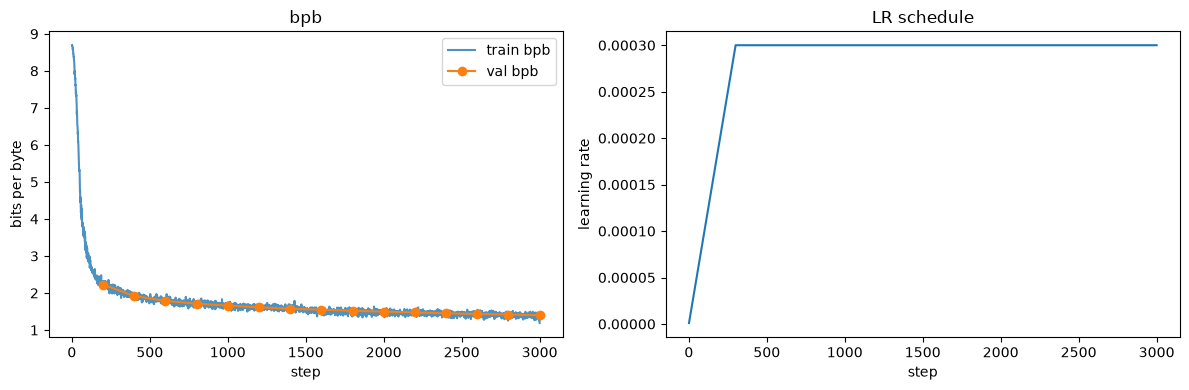

Best val bpb achieved: 1.3996


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["step"], history["train_bpb"], label="train bpb", alpha=0.8)
if val_history["step"]:
    axes[0].plot(val_history["step"], val_history["val_bpb"], label="val bpb", marker="o")
axes[0].set_xlabel("step"); axes[0].set_ylabel("bits per byte"); axes[0].legend(); axes[0].set_title("bpb")

axes[1].plot(history["step"], history["lr"])
axes[1].set_xlabel("step"); axes[1].set_ylabel("learning rate"); axes[1].set_title("LR schedule")
plt.tight_layout()
plt.show()

print(f"Best val bpb achieved: {best_val_bpb:.4f}")


## 10. Results

*This section is a template — fill it in with numbers from your own real
training run before publishing the notebook. For a public guide it's
generally worth showing at least one real run (hardware, wall-clock time,
final bpb, and a plot), so readers can judge whether the setup actually
works and roughly how expensive it is. If you only want a pure how-to
guide with no specific run attached, you can also just delete this
section.*

| | |
|---|---|
| Hardware | Kaggle TPU v5e-8 (8 cores) |
| Mesh (`USE_MESH`) | `"auto"` -> ON, 8 devices |
| `MODEL_CONFIG` | `vocab_size=256, d_model=768, n_heads=6, num_layers=7, mlp_mult=3, dropout_rate=0.0` (≈70.5M parameters) |
| `RUN_CONFIG` | `seq_len=2048, micro_batch_size=8, accum_steps=4, total_train_steps=3000, warmup_steps=300, peak_lr=3e-4, min_lr=1e-6, lr_reduce_factor=0.5, patience=3, lr_cooldown_steps=400, weight_decay=0.01, grad_clip_norm=1.0, eval_every_steps=200, eval_batches=20` |
| Total training wall-clock time | 3250.2 s (~54 min) |
| Final train bpb | 1.1883 |
| **Best val bpb** | **1.3996** |
| Non‑finite / auto‑stop events | none (0) |

This run reached **1.40 bpb** on enwik8 validation in about 54 minutes on an 8‑chip TPU v5e‑8. The training was stable – no non‑finite gradients or auto‑stop triggers were observed. The plateau‑adaptive LR schedule did not reduce the learning rate during the 3000 steps, meaning the model could likely benefit from longer training (e.g., 10-20k steps) to push bpb further into the ~1.2–1.3 range, as seen in the project's own scaling experiments. The notebook serves as a reproducible template; you can adjust `total_train_steps` and batch sizes to match your hardware budget.


```
[DONE] step=3000 best_val_bpb=1.3996 final_lr_mult=1.0000 total_reduces=0
```


## Notes

- **Package.** All GDN-2 mixing goes through the public
  `gdn2_forward_trainable` from `atomic_ops` (`pip install atomic-ops`):
  auto-dispatch, using the fused Pallas kernels on TPU with `d_head=128`,
  otherwise (CPU/GPU/other `d_head`) falling back to the validated
  pure-JAX chunked-WY path. See the
  [package README](https://github.com/Akseleu-J/atomic_ops) for the full
  API and benchmarks.
- **Data-parallel mesh.** On a multi-chip TPU slice (Kaggle TPU v5e-8 has
  8 chips), a plain `jax.jit` with no sharding runs everything on a single
  chip -- the rest sit idle, and the fused GDN-2 kernel itself does not
  get any faster or slower for it, you're just not using 7/8 of the
  hardware you paid for. Setting `USE_MESH = "auto"` (the default) detects
  this automatically and switches on a data-parallel mesh across all
  visible devices, wrapping the GDN-2 kernel call in `jax.shard_map` so
  each chip processes its own batch slice concurrently -- the same
  approach used in the project's own multi-chip training script
  (`train_gdn2_100m.py` / `model_gdn2_100m.py`). On CPU, GPU, or a single
  visible TPU chip, `USE_MESH="auto"` transparently falls back to
  unsharded execution -- no code changes needed either way. Use
  `USE_MESH=False` if you specifically want to measure the single-chip
  baseline on multi-chip hardware, or `USE_MESH=True` to force the mesh
  path even with one visible device (mostly for debugging the sharding
  code itself).
- **Scale.** The `MODEL_CONFIG`/`RUN_CONFIG` above is a starting point at
  ~70-75M parameters with a short (demo-sized) `total_train_steps`. For a
  real run on TPU v5e-8, increase `total_train_steps` (tens of thousands),
  tune `micro_batch_size`/`accum_steps` to the available HBM (remember
  `micro_batch_size` must divide evenly across devices when the mesh is
  on), and consult `atomic_ops.get_recommended_config` if you increase
  `seq_len`.
- **Stability.** The non-finite guard skips (rather than crashes) a step on
  NaN/Inf in the gradient; the auto-stop fires on sustained instability
  (see `nonfinite_consecutive_limit` / `nonfinite_window_*`) — the same
  principle used in the project's own training pipeline.
- **Checkpoints** are plain `flax.serialization` `.msgpack` files
  (`ckpt_dir/{latest,best_val,final,auto_stop}.msgpack`), with no extra
  dependencies (Orbax/HF); swap in `orbax.checkpoint` for async
  checkpointing if you scale this up to longer runs.
